In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

# calculation
# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

Number of CPUs: 256, number of threads: 8, number of workers: 32


In [2]:
def mask_cal(dset):
    ##This function calculate the land_sea mask according to the resolution of the data##
    ###negative values is ocean, positive values is land
    filemask = '/work/mh0731/from_Mistral/mh0731/m300876/land_sea_mask/GPM_IMERG_LandSeaMask.2.nc4'
    dsetmask = xr.open_dataset(filemask)
    lsmask01 = dsetmask.landseamask.where(
        dsetmask.landseamask<100).interp(lon=dset.lon.values,lat=dset.lat.values,method='linear') *0 +2
    lsmask01 = lsmask01.where(lsmask01==2,-2)
    return lsmask01

In [3]:
def time_mean_imerg_multi(file,lat,lon,environ):
    ##Funtion to calculate the climatology monthly mean of precipitation from IMERG
    ###the environ option mask the values over land or ocean:
        ## if environ = 'trop' -> no mask is used
        ## if environ = 'ocean' -> return only values over ocean
        ## if environ = 'land' -> return only values over land
    data = xr.open_mfdataset(
        file, combine='by_coords',engine='netcdf4',chunks=({'time':20}))['calibrated_precipitation']
    if environ == 'trop':
        pr=data.sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
    else:
        lsmask01 = mask_cal(data)
        if environ == 'ocean':
            pr=data.where(lsmask01<0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        elif environ == 'land':
            pr=data.where(lsmask01>0).sel(lat=slice(lat[0],lat[1]),lon=slice(lon[0],lon[1]))
        else:
            return print('Something is wrong')
    
    prmon = pr.resample(time='1H').mean(dim='time')
    prmon_clim = prmon.groupby('time.hour').mean(dim='time')
    
    jobs = dask.persist(prmon) # prmon_clim (month, lat, lon) for the mean/ prmon (year, month, lat, lon) for the std
    progress(jobs, notebook=False)
    precip = dask.compute(prmon) # prmon_clim
    
    return precip[0]

In [4]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

## Precipitation

## 1. Load IMERG data

_Regird from original data_

In [5]:
#Define a global pattern to find the files
glob_pattern_3d1 = 'IMERG_precipitationrate_2020*_AMZcrop*' # 10km * 10km
## Define the paths
#data_path1 = Path('/pool/data/ICDC/atmosphere/imerg/DATA/2020')
data_path1 = Path('/scratch/m/m300948/IMERG')

## Collect all file names with pathlib's rglob and list compression  
file_imerg = sorted([str(f) for f in data_path1.rglob(f'*{glob_pattern_3d1}')])[:]

In [6]:
file_imerg

['/scratch/m/m300948/IMERG/IMERG_precipitationrate_202001_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202002_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202003_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202004_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202005_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202006_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202007_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202008_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202009_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202010_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202011_AMZcrop.nc',
 '/scratch/m/m300948/IMERG/IMERG_precipitationrate_202012_AMZcrop.nc']

In [7]:
pr_imerg = xr.open_mfdataset(file_imerg)['calibrated_precipitation']

In [8]:
ABinterp_biome_imerg = AMZ_BD.interp(latitude=pr_imerg.lat, longitude=pr_imerg.lon)
imerg_mult_amz = pr_imerg.where(ABinterp_biome_imerg==0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [9]:
# IMERG X2!!!! 
pr_imerg_amz_hourly = imerg_mult_amz.resample(time='1H').sum(dim='time')

In [10]:
pr_imerg_amz_hourly.to_netcdf('/scratch/m/m300948/IMERG/amz_hourly/pr_imerg_amz_hourly_2020_amz.nc')

In [11]:
xarray_names = ['pr_imerg_amz_hourly']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

## 2. ICON

_Original_

In [ ]:
# original
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_hourly_pr_2020_imerg.nc',parallel=True)['pr']
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')

AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)

pr_ctl_mask = pr_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
pr_ctl_hour_mask = pr_ctl_mask.resample(time='H').mean()

_ERA5_

In [40]:
# Regridded
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_hourly_pr_202*_on_imerg*',parallel=True)['pr']
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')

In [27]:
# flip the latitude
pr_ctl_flipped = pr_ctl.isel(latitude=slice(None, None, -1))

In [28]:
# reset the longitude
# Fix longitude to range -180 to 180
pr_ctl_edit = pr_ctl_flipped.assign_coords(
    longitude=(((pr_ctl_flipped.longitude + 180) % 360) - 180)
)

# Then sort, so the values go from -180 → 180
pr_ctl_edit = pr_ctl_edit.sortby("longitude")

In [ ]:
# ERA5
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=pr_ctl_edit.latitude, longitude=pr_ctl_edit.longitude)

pr_ctl_edit_mask = pr_ctl_edit.where(ABinterp_biome == 0, np.nan).sel(longitude=slice(-80,-40), latitude=slice(-20,10))
pr_ctl_edit_hour_mask = pr_ctl_edit_mask.resample(time='H').mean()

_IMERG (after regrid the dataset)_

In [12]:
# Regridded
pr_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/ctl_hourly_pr_2020_imerg.nc',parallel=True)['pr']
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')

In [13]:
# imerg
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=pr_ctl.latitude, longitude=pr_ctl.longitude)

pr_ctl_mask = pr_ctl.where(ABinterp_biome == 0, np.nan).sel(longitude=slice(-80,-40), latitude=slice(-20,10))
pr_ctl_hour_mask = pr_ctl_mask.resample(time='H').mean()

In [28]:
pr_ctl_day_mask = pr_ctl_mask.resample(time='D').mean()

In [14]:
pr_ctl_mm_hour_mask = (pr_ctl_hour_mask*3600).compute()

In [29]:
pr_ctl_day_day_mask = (pr_ctl_hour_mask*3600*24).compute()

In [15]:
pr_ctl_mm_hour_mask.to_netcdf('/scratch/m/m300948/test_04/pr/pr_ctl_mm_hour_mask_2020.nc')

## PDF

_Load IMERG AND ICON_

In [16]:
pr_imerg_amz_hourly = xr.open_dataset('/scratch/m/m300948/IMERG/amz_hourly/pr_imerg_amz_hourly_2020_amz.nc')
pr_ctl_mm_hour_mask = xr.open_mfdataset('/scratch/m/m300948/test_04/pr/pr_ctl_mm_hour_mask_2020.nc')

In [17]:
xarray_names = ['pr_ctl_mm_hour_mask'] #'pr_ctl_mm_hour_amz_interp']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.pr.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [13]:
xarray_names = ['pr_imerg_amz_hourly']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.calibrated_precipitation.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

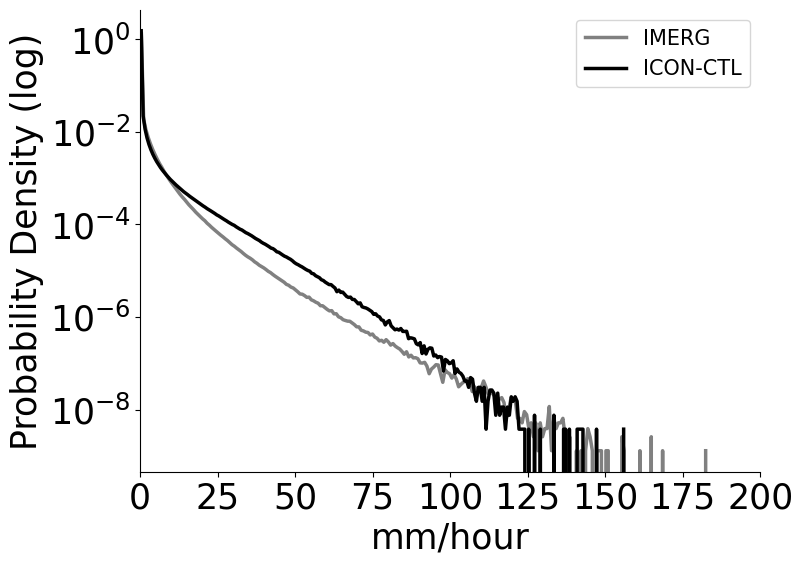

In [18]:
## Second trial 
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(pr_imerg_amz_hourly_f, bins=250, density=True)
pdf_def, bin_edges_def = np.histogram(pr_ctl_mm_hour_mask_f, bins=250, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl, pdf_ctl, label='IMERG', color='grey', linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='ICON-CTL', color='black', linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')

plt.xlim(0, 200)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
plt.legend(fontsize=15)

# Display the plot
plt.show()

In [27]:
print(np.max(pr_ctl_mm_hour_mask_f))
print(np.max(pr_imerg_amz_hourly_f))

156.2504
182.76


In [19]:
import numpy as np

# --- 1. Interpolate both PDFs to a common set of bins ---
# Make sure the comparison is one-to-one in x
common_bins = np.linspace(0, 200, 1000)  # fine grid
pdf_imerg_interp = np.interp(common_bins, bin_centers_ctl, pdf_ctl)
pdf_icon_interp  = np.interp(common_bins, bin_centers_def, pdf_def)

# --- 2. Find where ICON > IMERG ---
mask = pdf_icon_interp > pdf_imerg_interp

# --- 3. Identify contiguous precipitation ranges where ICON > IMERG ---
ranges = []
if np.any(mask):
    idx = np.where(mask)[0]
    split_points = np.where(np.diff(idx) > 1)[0]
    start_idx = np.r_[idx[0], idx[split_points + 1]]
    end_idx   = np.r_[idx[split_points], idx[-1]]

    for s, e in zip(start_idx, end_idx):
        ranges.append((common_bins[s], common_bins[e]))

print("Precipitation ranges where ICON has higher probability density than IMERG:")
for r in ranges:
    print(f"  {r[0]:.1f} – {r[1]:.1f} mm/hour")

# --- 4. Compute total probability mass (fraction of events) in those ranges ---
# approximate by trapezoidal area under each PDF in the regions
icon_prob = 0
imerg_prob = 0
for s, e in ranges:
    mask_range = (common_bins >= s) & (common_bins <= e)
    icon_prob += np.trapz(pdf_icon_interp[mask_range], common_bins[mask_range])
    imerg_prob += np.trapz(pdf_imerg_interp[mask_range], common_bins[mask_range])

print(f"\nFraction of total events where ICON > IMERG:")
print(f"  ICON:  {icon_prob:.4e}  ({icon_prob*100:.3f}%)")
print(f"  IMERG: {imerg_prob:.4e}  ({imerg_prob*100:.3f}%)")

Precipitation ranges where ICON has higher probability density than IMERG:
  0.0 – 0.4 mm/hour
  1.2 – 1.2 mm/hour
  8.4 – 104.9 mm/hour
  106.3 – 107.5 mm/hour
  109.1 – 109.7 mm/hour
  112.7 – 114.1 mm/hour
  115.1 – 115.5 mm/hour
  118.1 – 118.7 mm/hour
  119.7 – 119.9 mm/hour
  120.5 – 121.9 mm/hour
  126.9 – 127.3 mm/hour
  133.3 – 133.5 mm/hour
  136.9 – 138.7 mm/hour
  140.5 – 143.1 mm/hour
  146.7 – 147.5 mm/hour
  155.8 – 200.0 mm/hour

Fraction of total events where ICON > IMERG:
  ICON:  5.9666e-01  (59.666%)
  IMERG: 5.2097e-01  (52.097%)


In [25]:
import numpy as np

# --- assuming your ICON rainfall data is in mm/hour ---
icon = pr_imerg_amz_hourly_f

low, high = 10, 120  # mm/hour bounds (0.759%)

# total number of ICON events
total_events = len(icon)

# number of events between 10 and 120 mm/hour
events_in_range = np.sum((icon >= low) & (icon <= high))

# percentage (frequency of occurrence)
percentage = (events_in_range / total_events) * 100

print(f"ICON events between {low}–{high} mm/hour: {events_in_range} / {total_events} "
      f"({percentage:.3f}%)")

ICON events between 10–120 mm/hour: 4830919 / 1054080000 (0.458%)


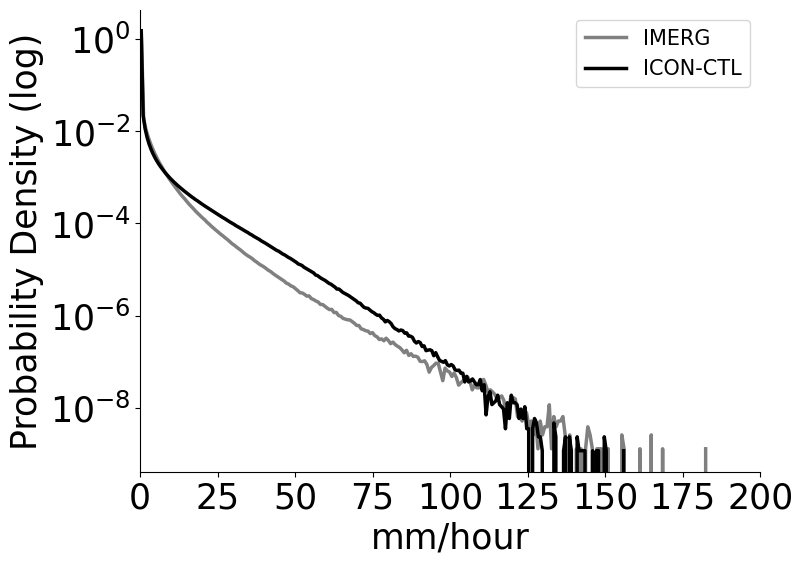

In [15]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(pr_imerg_amz_hourly_f, bins=250, density=True)
pdf_def, bin_edges_def = np.histogram(pr_ctl_mm_hour_mask_f, bins=250, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl, pdf_ctl, label='IMERG', color='grey', linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='ICON-CTL', color='black', linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')

plt.xlim(0, 200)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
plt.legend(fontsize=15)

# Display the plot
plt.show()

In [21]:
ctl_hour_q99 = np.nanquantile(pr_imerg_amz_hourly_f, 0.99, axis=0)
print(ctl_hour_q99)

6.0


In [22]:
#ctl_hour_q99 = np.nanquantile(pr_ctl_mm_hour_amz_interp_f, 0.99, axis=0)
ctl_hour_q99 = np.nanquantile(pr_ctl_mm_hour_mask_f, 0.99, axis=0)

print(ctl_hour_q99)

7.858522


## Percentage

In [16]:
pr_imerg_mm_hour_mask_f = pr_imerg_amz_hourly_f 

In [18]:
# Hourly precipitation
xarray_names = ['pr_ctl_mm_hour','pr_imerg_mm_hour']
new_suffix = ['_norain','_light','_moderate','_heavy','_violent']

for name in xarray_names:
    for suffix in new_suffix:
        dsetname = name + '_mask_f'
        xarray_data = globals()[dsetname]
        if suffix == '_norain':
            xarray_data_f = xarray_data[xarray_data == 0]
        if suffix == '_light':
            xarray_data_f = xarray_data[(xarray_data > 0) & (xarray_data <= 2.5)]
        elif suffix == '_moderate':
            xarray_data_f = xarray_data[(xarray_data > 2.5) & (xarray_data <= 10)]
        elif suffix == '_heavy':
            xarray_data_f = xarray_data[(xarray_data > 10) & (xarray_data <= 50)]
        elif suffix == '_violent':
            xarray_data_f = xarray_data[xarray_data > 50]
        new_name = name + suffix
        globals()[new_name] = xarray_data_f

In [28]:
# hourly precipitation
import pandas as pd
df = pd.DataFrame({
    'Category': ['No_rain', 'Light', 'Moderate', 'Heavy', 'Violent'],
    'CTL': [len(pr_ctl_mm_hour_norain), len(pr_ctl_mm_hour_light), len(pr_ctl_mm_hour_moderate), len(pr_ctl_mm_hour_heavy), len(pr_ctl_mm_hour_violent)],
    'IMERG': [len(pr_imerg_mm_hour_norain), len(pr_imerg_mm_hour_light), len(pr_imerg_mm_hour_moderate), len(pr_imerg_mm_hour_heavy), len(pr_imerg_mm_hour_violent)]
})

In [29]:
print(df['CTL']/len(pr_ctl_mm_hour_mask_f)*100)
print(df['IMERG']/len(pr_imerg_mm_hour_mask_f)*100)

0     0.003459
1    97.507096
2     1.722903
3     0.751609
4     0.014933
Name: CTL, dtype: float64
0    91.611602
1     5.929378
2     2.001479
3     0.453296
4     0.004245
Name: IMERG, dtype: float64


### 2) Area-weighted

In [42]:
import numpy as np
import xarray as xr
import xesmf as xe

# --- 0) Ensure longitudes align ---
# Bring both to [0, 360) or [-180, 180). Here we choose [-180, 180)
def wrap_lon(ds, lon_name='lon'):
    lon = ds[lon_name]
    if lon.max() > 180:
        ds = ds.assign_coords({lon_name: ((lon + 180) % 360) - 180}).sortby(lon_name)
    return ds

icon = wrap_lon(pr_ctl_mm_hour_mask.to_dataset(name='pr'))  # (time, lat, lon) in mm/hr
imerg = wrap_lon(imerg_mult_amz.to_dataset(name='pr'))      # (time, lat, lon) or at least lat/lon grid


In [43]:
# --- 1) Build grid dicts with cell bounds (needed for conservative regridding) ---
def centers_to_bounds(centers):
    """Compute bounds from 1D center coords by midpoints; extrapolate at edges."""
    c = centers.values
    mid = 0.5 * (c[1:] + c[:-1])
    first = c[0] - (mid[0] - c[0])
    last  = c[-1] + (c[-1] - mid[-1])
    bounds = np.concatenate([[first], mid, [last]])
    return xr.DataArray(bounds, dims=[centers.dims[0]+"_b"])

def make_grid(ds, lat_name='lat', lon_name='lon'):
    lat = ds[lat_name]; lon = ds[lon_name]
    lat_b = centers_to_bounds(lat); lon_b = centers_to_bounds(lon)
    # 2D meshes
    lon2, lat2 = xr.broadcast(lon, lat)
    lonb2, latb2 = xr.broadcast(lon_b, lat_b)
    return {
        'lon': lon2, 'lat': lat2,
        'lon_b': lonb2, 'lat_b': latb2
    }

src_grid = make_grid(pr_ctl_mm_hour_mask,  lat_name='lat', lon_name='lon')   # ICON grid
tgt_grid = make_grid(imerg_mult_amz, lat_name='lat', lon_name='lon')   # IMERG 0.1° grid

In [44]:
# --- 2) Create regridder (conservative, area-weighted) ---
regridder = xe.Regridder(
    src_grid, tgt_grid,
    method='conservative_normed',
    periodic=False,           # good for global grids with wrap-around
    reuse_weights=False,      # cache weights to disk for reuse
)

In [45]:
# --- 3) Apply to precipitation (lazy over time if dask-backed) ---
# icon['pr'] has dims (time, lat, lon) in mm/hr
pr_ctl_mm_hour_amz_areaw = regridder(icon['pr'])

# pr_ctl_mm_hour_amz_areaw now matches IMERG's lat/lon grid with area-weighted values

In [46]:
# --------- NAN-SAFE REMAP (key part) ----------
# 1) Regrid the data with NaNs filled as 0 (numerator)
num = regridder(icon.fillna(0.0))

# 2) Regrid a 0/1 validity mask to get the effective contributing-area fraction
valid = xr.where(np.isfinite(icon), 1.0, 0.0)
W = regridder(valid)

# 3) Renormalize: divide by contributing fraction where it’s >0
icon_aw = num / W.where(W > 0)

In [47]:
icon_aw

<xarray.Dataset> Size: 152MB
Dimensions:    (time: 8328, lon: 53, lat: 43)
Coordinates:
  * time       (time) datetime64[ns] 67kB 2020-01-20 ... 2020-12-31T23:00:00
    lat        (lon, lat) float64 18kB -29.5 -28.5 -27.5 ... 10.5 11.5 12.5
    latitude   (lat) float64 344B -29.5 -28.5 -27.5 -26.5 ... 9.5 10.5 11.5 12.5
    lon        (lon, lat) float64 18kB -82.0 -82.0 -82.0 ... -30.0 -30.0 -30.0
    longitude  (lon) float64 424B -82.0 -81.0 -80.0 -79.0 ... -32.0 -31.0 -30.0
Data variables:
    pr         (time, lon, lat) float64 152MB nan nan nan nan ... nan nan nan

In [105]:
xarray_names = ['icon_aw'] #,'pr_ctl_mm_hour_amz_areaw']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.pr.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [ ]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(imerg_mult_amz_f, bins=250, density=True) # imerg
pdf_def, bin_edges_def = np.histogram(icon_aw_f, bins=250, density=True) # icon

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl, pdf_ctl, label='IMERG', color='black', linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='ICON-CTL', color='grey', linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')

plt.xlim(0, 100)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
plt.legend(fontsize=15)

# Display the plot
plt.show()

In [107]:
ctl_hour_q99 = np.nanquantile(imerg_mult_amz_f, 0.90, axis=0)
print(ctl_hour_q99)

def_hour_p99 = np.nanquantile(icon_aw_f, 0.90, axis=0)
print(def_hour_p99)

0.47499320625935054
0.9519020498511905


### 3) Coarsen

In [2]:
import xesmf as xe

In [3]:
pr_ctl_hour_mask = xr.open_dataset('/scratch/m/m300948/test_04/pr_ctl_hour_mask.nc')
imerg_mult_amz = xr.open_dataset('/scratch/m/m300948/test_04/imerg_mult_amz.nc')

In [67]:
pr_ctl_hour_mask.pr

<xarray.DataArray 'pr' (time: 8737, lat: 300, lon: 400)>
[1048440000 values with dtype=float32]
Coordinates:
  * lon        (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
  * lat        (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
  * time       (time) datetime64[ns] 2022-01-01 ... 2022-12-31
    latitude   (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    longitude  (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
Attributes:
    standard_name:  pr
    long_name:      precipitation flux
    units:          kg m-2 s-1
    param:          52.1.0

In [68]:
imerg_mult_amz.calibrated_precipitation

<xarray.DataArray 'calibrated_precipitation' (time: 8784, lat: 30, lon: 41)>
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]])
Coordinates:
  * lon        (lon) float64 -80.0 -79.0 -78.0 -77.0 ... -43.0 -42.0 -41.0 -40.0
  * lat        (lat) float64 -19.5 -18.5 -17.5 -16.5 -15.5 ... 6.5 7.5 8.5 9.5
  * time       (time) datetime64[ns] 2020-01-01 ... 2020-12-31T23:00:00
    latitude   (lat) float64 -19.5 -18.5 -17.5 -16.5 -15.5 ... 6.5 7.5 8.5 9.5
    longitude  (lon) float64 -80.0 -79.0 -78.0 -77.0 ... -43.0 -42.0 -41.0 -40.0
Attributes:
    long_name:     multi_satellite_calibrated_precipitation
    units:         mm/h
    cell_methods:  time: mean
    comment:       This is the multi-satellite precipitation rate calibrated ...

In [31]:
pr_ctl = pr_ctl_hour_mask.pr.drop_vars(['latitude','longitude'])

In [32]:
imerg_pr = imerg_mult_amz.calibrated_precipitation.drop_vars(['latitude','longitude'])

In [61]:
grid_in = {
    "lon": pr_ctl.lon.values,
    "lat": pr_ctl.lat.values,
    "lon_b": np.linspace(pr_ctl.lon.min()-0.5, pr_ctl.lon.max()+0.5, len(pr_ctl.lon)+1),
    "lat_b": np.linspace(pr_ctl.lat.min()-0.5, pr_ctl.lat.max()+0.5, len(pr_ctl.lat)+1),
}

grid_out = {
    "lon": imerg_pr.lon.values,
    "lat": imerg_pr.lat.values,
    "lon_b": np.linspace(imerg_pr.lon.min()-0.5, imerg_pr.lon.max()+0.5, len(imerg_pr.lon)+1),
    "lat_b": np.linspace(imerg_pr.lat.min()-0.5, imerg_pr.lat.max()+0.5, len(imerg_pr.lat)+1),
}

regridder_conservative = xe.Regridder(grid_in, grid_out, method="conservative_normed", ignore_degenerate=True)
regridder_near = xe.Regridder(grid_in, grid_out, method="nearest_s2d", ignore_degenerate=True)
regridder_bilinear = xe.Regridder(grid_in, grid_out, method="bilinear", ignore_degenerate=True)

In [62]:
ds_icon_conservative = regridder_conservative(pr_ctl)
ds_icon_near = regridder_near(pr_ctl)
ds_icon_bilinear = regridder_bilinear(pr_ctl)

In [63]:
xarray_names = ['ds_icon_conservative','ds_icon_near','ds_icon_bilinear'] #'pr_ctl_mm_hour_amz_interp']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [41]:
np.size(ds_icon_regridded_f)

4191434

In [42]:
xarray_names = ['imerg_mult_amz'] #'pr_ctl_mm_hour_amz_interp']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.calibrated_precipitation.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [43]:
np.size(imerg_mult_amz_f)

4721640

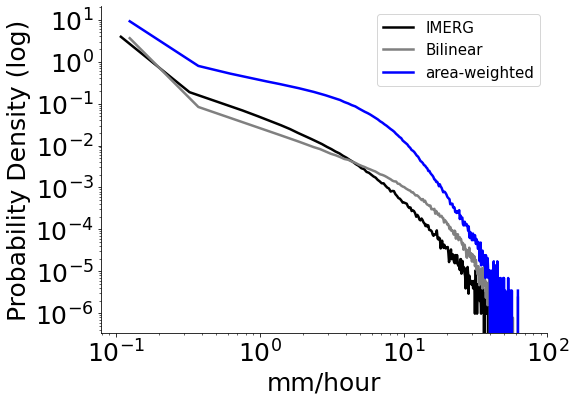

In [73]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(imerg_mult_amz_f, bins=250, density=True) # imerg
pdf_def_b, bin_edges_def_b = np.histogram(ds_icon_bilinear_f*3600, bins=250, density=True) # icon
pdf_def_n, bin_edges_def_n = np.histogram(ds_icon_near_f*3600, bins=250, density=True) # icon
pdf_def_c, bin_edges_def_c = np.histogram(ds_icon_conservative_f*3600, bins=250, density=True) # icon

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def_b[1:] + bin_edges_def_b[:-1])

# Plot the PDF
clr = ['darkkhaki', 'darkkhaki', 'darkkhaki', 'thistle', 'thistle', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl, pdf_ctl, label='IMERG', color='black', linewidth=2.5)
plt.plot(bin_centers_def, pdf_def_b, label='Bilinear', color='gray', linewidth=2.5)
plt.plot(bin_centers_def, pdf_def_c, label='area-weighted', color='blue', linewidth=2.5)
#plt.plot(bin_centers_def, pdf_def_n, label='near', color='red', linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xscale('log')

plt.xlim(0, 100)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
plt.legend(fontsize=15)

# Display the plot
plt.show()

## Spatial pattern

In [163]:
def contourf(data, vmin, vmax, space, cmap, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80,-40,-19,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    #m = data.sum('hour').plot(levels=np.linspace(0, 20, 10), extend='max', cmap='YlGnBu', transform=ccrs.PlateCarree())
    #m = ax.pcolormesh(lons,lats,data.sum('hour'),cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    
     # Add contour line at values >= 10
    cs = ax.contour(
        lons,
        lats,
        data,
        levels=[100],                # draw the contour at value 10
        colors='red',               # choose color for the line
        linewidths=2.0,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, fmt="%d", fontsize=15)  

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, space)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    plt.title(title, fontsize='20')
    plt.show()

In [ ]:
# IMERG: 4.472501192518554, 0.47
# ICON: 7.777236,  0.08, (interpolated) 0.95

_separate seasons_

In [113]:
# IMERG
convg_imerg_wet = pr_imerg_amz_hourly.sel(time=slice('2020-01-20','2020-12-31')).calibrated_precipitation.sel(time=pr_imerg_amz_hourly.sel(time=slice('2020-01-20','2020-12-31'))['time'].dt.month.isin([12, 1, 2]))
convg_imerg_dry = pr_imerg_amz_hourly.calibrated_precipitation.sel(time=pr_imerg_amz_hourly['time'].dt.month.isin([7, 8, 9]))

In [65]:
# ICON
convg_icon_wet = pr_ctl_mm_hour_mask.pr.sel(time=pr_ctl_mm_hour_mask['time'].dt.month.isin([12, 1, 2])).rename({'latitude':'lat','longitude':'lon'})
convg_icon_dry = pr_ctl_mm_hour_mask.pr.sel(time=pr_ctl_mm_hour_mask['time'].dt.month.isin([7, 8, 9])).rename({'latitude':'lat','longitude':'lon'})

In [145]:
convg_imerg_wet_coarse = convg_imerg_wet.coarsen(lat=2, lon=2, boundary='trim').mean()
convg_imerg_dry_coarse = convg_imerg_dry.coarsen(lat=2, lon=2, boundary='trim').mean()

In [146]:
convg_icon_wet_coarse = convg_icon_wet.coarsen(lat=2, lon=2, boundary='trim').mean()
convg_icon_dry_coarse = convg_icon_dry.coarsen(lat=2, lon=2, boundary='trim').mean()

## violent rains

In [154]:
violent_mask_imerg_wet = convg_imerg_wet_coarse > 10
violent_mask_imerg_dry = convg_imerg_dry_coarse > 10
violent_mask_icon_wet = convg_icon_wet_coarse > 10
violent_mask_icon_dry = convg_icon_dry_coarse > 10

In [155]:
pr_imerg_wet_violent = convg_imerg_wet_coarse.where(violent_mask_imerg_wet)
pr_imerg_dry_violent = convg_imerg_dry_coarse.where(violent_mask_imerg_dry)

In [156]:
pr_icon_wet_violent = convg_icon_wet_coarse.where(violent_mask_icon_wet)
pr_icon_dry_violent = convg_icon_dry_coarse.where(violent_mask_icon_dry)

In [157]:
pr_imerg_wet_violent_count = pr_imerg_wet_violent.count(dim='time') 
pr_imerg_dry_violent_count = pr_imerg_dry_violent.count(dim='time') 

In [158]:
pr_icon_wet_violent_count = pr_icon_wet_violent.count(dim='time') 
pr_icon_dry_violent_count = pr_icon_dry_violent.count(dim='time') 

In [41]:
print(pr_imerg_wet_violent_count.max())
pr_icon_wet_violent_count.values.max()

<xarray.DataArray 'calibrated_precipitation' ()> Size: 8B
array(135)


np.int64(876)

In [42]:
print(pr_imerg_dry_violent_count.max())
print(pr_icon_dry_violent_count.values.max())

<xarray.DataArray 'calibrated_precipitation' ()> Size: 8B
array(114)
655


In [86]:
print(convg_imerg_wet_coarse.time.sizes)
print(convg_icon_wet_coarse.time.sizes)

Frozen({'time': 2184})
Frozen({'time': 1728})


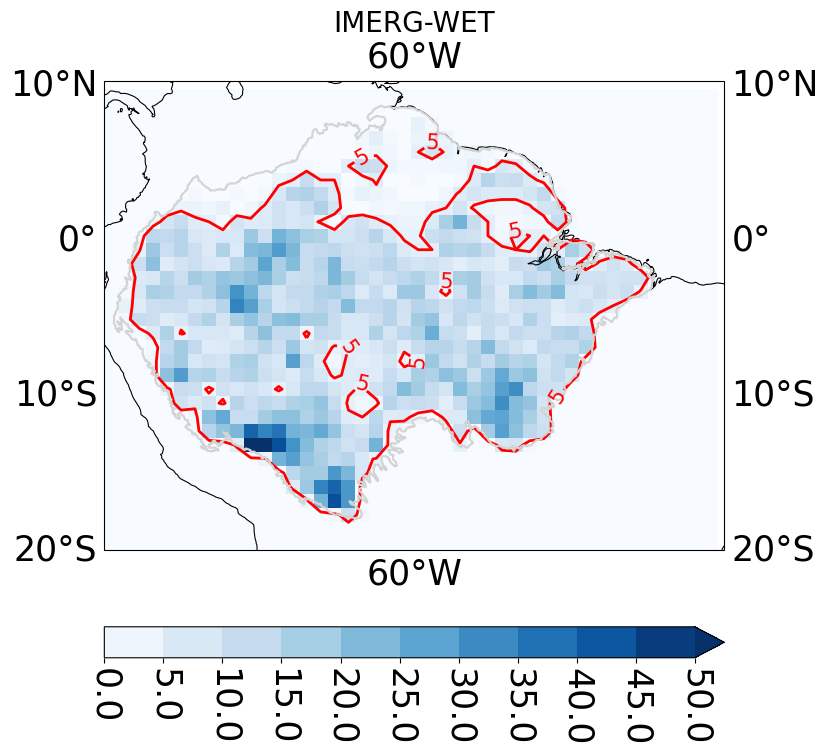

In [142]:
contourf(pr_imerg_wet_violent_count, 0, 50, 11, 'Blues', 'max','IMERG-WET') # 23500-25500 # /pr_imerg_wet_violent.time.size*100

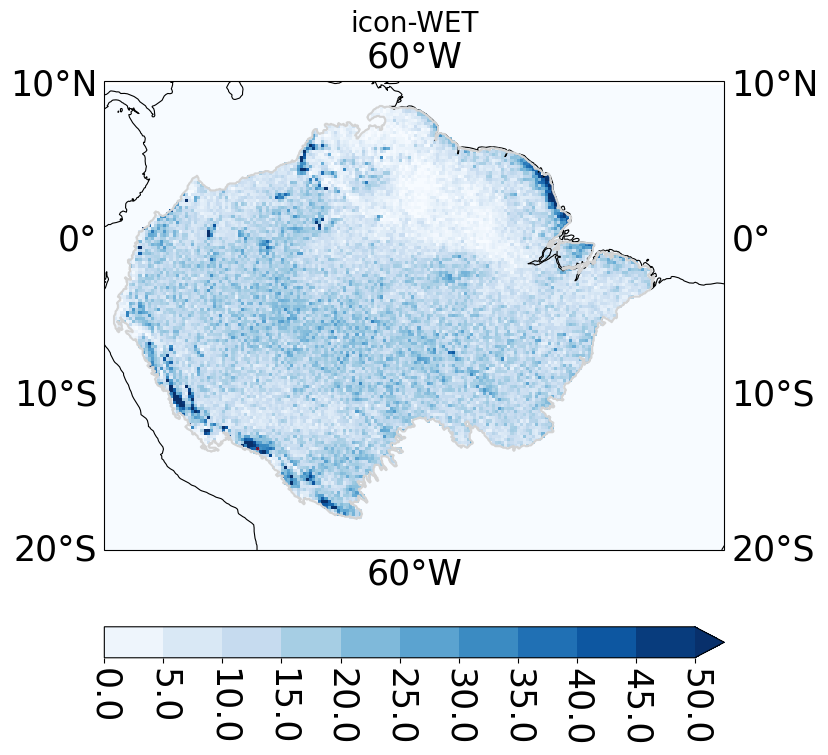

In [164]:
contourf(pr_icon_wet_violent_count, 0, 50, 11, 'Blues', 'max','icon-WET') # 23500-25500 # /pr_icon_wet_violent.time.size*100

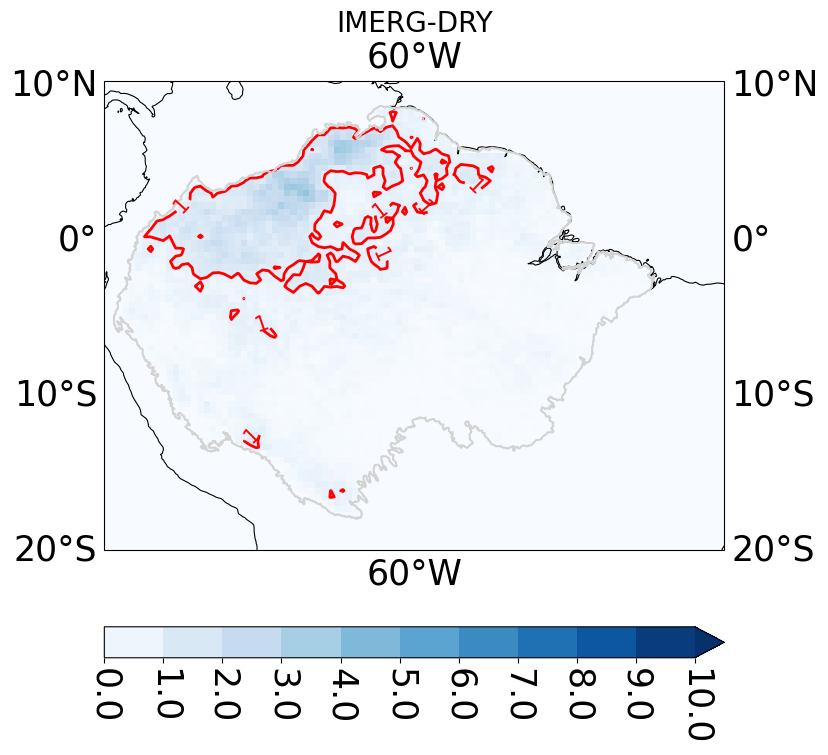

In [103]:
contourf(pr_imerg_dry_violent_count/2184 * 100, 0, 10, 11, 'Blues', 'max','IMERG-DRY') # 23500-25500, /pr_imerg_dry_violent.time.size*100

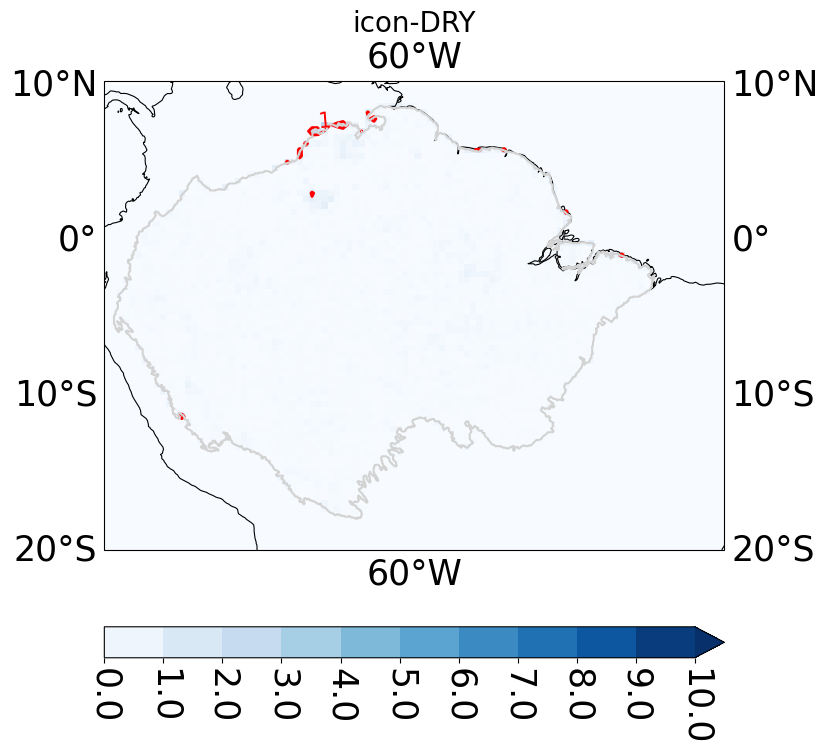

In [104]:
contourf(pr_icon_dry_violent_count/1728*100, 0, 10, 11, 'Blues', 'max','icon-DRY') # 23500-25500, /pr_icon_dry_violent.time.size*100

## flattens and q90

In [28]:
# seasonal quantile 90
xarray_names = ['convg_imerg_wet', 'convg_imerg_dry', 'convg_icon_wet', 'convg_icon_dry']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [ ]:
# whole year quantile 90
xarray_names = ['imerg_pr', 'ds_icon_conservative']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [38]:
# q90 for wa
new_suffix = '_q90'

xarray_names = ['convg_imerg_wet', 'convg_imerg_dry', 'convg_icon_wet', 'convg_icon_dry']

for name in xarray_names:
    dset_name = name + '_f' 
    xarray_data = globals()[dset_name]
    xarray_data_q99 = np.nanquantile(xarray_data, 0.9, axis=0)

    new_name = dset_name + new_suffix
    globals()[new_name] = xarray_data_q99

In [ ]:
# q90 for wa
new_suffix = '_q90'

xarray_names = ['imerg_pr', 'ds_icon_conservative']

for name in xarray_names:
    dset_name = name + '_f' 
    xarray_data = globals()[dset_name]
    xarray_data_q99 = np.nanquantile(xarray_data, 0.8, axis=0)

    new_name = dset_name + new_suffix
    globals()[new_name] = xarray_data_q99

_select values above q90_

In [41]:
# wet
imerg_mask_wet = (convg_imerg_wet > convg_imerg_wet_f_q90) 
icon_mask_wet = (convg_icon_wet > convg_icon_wet_f_q90) # same threshold

convg_imerg_wet_above_q90 = convg_imerg_wet.where(imerg_mask_wet) 
convg_icon_wet_above_q90 = convg_icon_wet.where(icon_mask_wet) 

In [42]:
# dry
imerg_mask_dry = (convg_imerg_dry > convg_imerg_dry_f_q90) 
icon_mask_dry = (convg_icon_dry > convg_icon_dry_f_q90) # same threshold

convg_imerg_dry_above_q90 = convg_imerg_dry.where(imerg_mask_dry) 
convg_icon_dry_above_q90 = convg_icon_dry.where(icon_mask_dry) 

In [39]:
print(convg_imerg_wet_f_q90, convg_icon_wet_f_q90)

0.049999997 0.20298281


In [40]:
print(convg_imerg_dry_f_q90, convg_icon_dry_f_q90)

0.0 0.012455174


In [43]:
# above q90
count_convg_wet_imerg = convg_imerg_wet_above_q90.count(dim='time') 
count_convg_wet_icon = convg_icon_wet_above_q90.count(dim='time')
count_convg_dry_imerg = convg_imerg_dry_above_q90.count(dim='time')
count_convg_dry_icon = convg_icon_dry_above_q90.count(dim='time')

In [19]:
count_convg_wet_imerg.compute()

<xarray.DataArray 'calibrated_precipitation' (lat: 300, lon: 400)> Size: 960kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 400))
Coordinates:
  * lon        (lon) float32 2kB -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
  * lat        (lat) float32 1kB -19.95 -19.85 -19.75 -19.65 ... 9.75 9.85 9.95
    latitude   (lat) float32 1kB -19.95 -19.85 -19.75 -19.65 ... 9.75 9.85 9.95
    longitude  (lon) float32 2kB -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05

In [ ]:
diff_freq_convg_wet = (count_convg_wet_imerg - count_convg_wet_icon).compute()
diff_freq_convg_dry = (count_convg_dry_imerg - count_convg_dry_icon).compute()

In [44]:
print(convg_imerg_wet_above_q90.time.size, convg_imerg_dry_above_q90.time.size, convg_icon_wet_above_q90.time.size, convg_imerg_dry_above_q90.time.size )

2184 2208 6025 2208


In [45]:
count_convg_wet_icon= count_convg_wet_icon.rename({'latitude':'lat','longitude':'lon'})

In [46]:
count_convg_dry_icon= count_convg_dry_icon.rename({'latitude':'lat','longitude':'lon'})

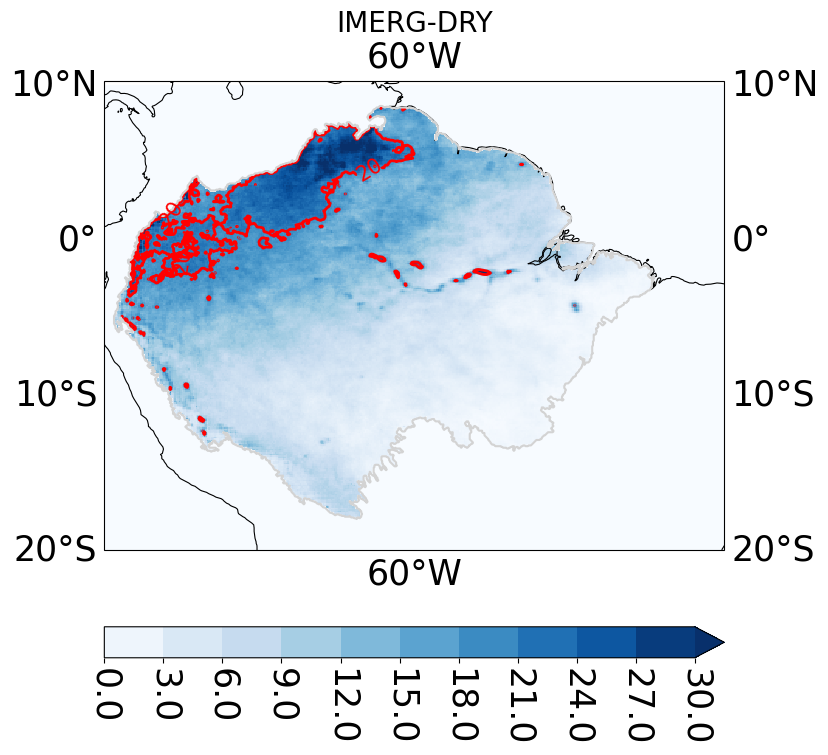

In [54]:
contourf(count_convg_dry_imerg/convg_imerg_dry_above_q90.time.size*100, 0, 30, 11, 'Blues', 'max','IMERG-DRY') # 23500-25500

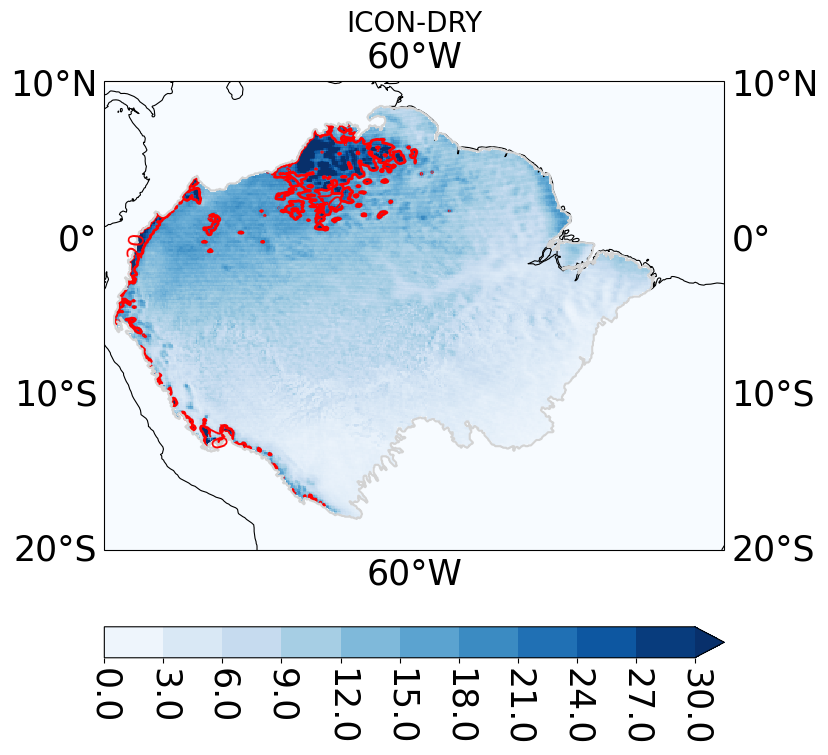

In [55]:
contourf(count_convg_dry_icon/convg_icon_dry_above_q90.time.size*100, 0, 30, 11, 'Blues', 'max','ICON-DRY') # 23500-25500

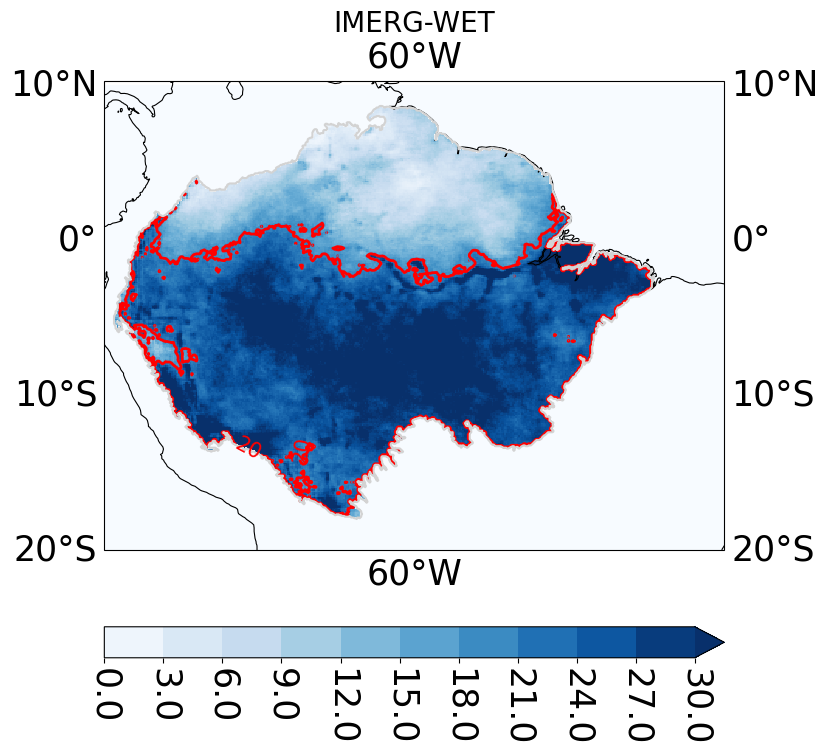

In [53]:
contourf(count_convg_wet_imerg/convg_imerg_wet_above_q90.time.size*100, 0, 30, 11, 'Blues', 'max','IMERG-WET') # 23500-25500

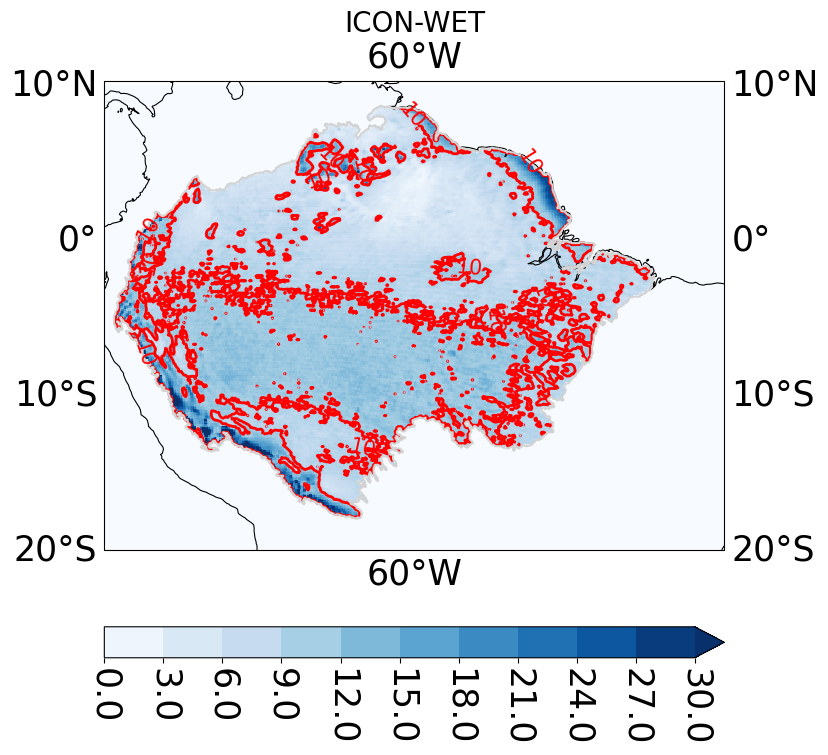

In [58]:
contourf(count_convg_wet_icon/convg_icon_wet_above_q90.time.size*100, 0, 30, 11, 'Blues', 'max','ICON-WET') # 23500-25500

In [105]:
import scipy.ndimage as ndimage
# Convg - Black contour, PR - Red contour, PR - Hatched
def contourf_wo_w(data_c, vmin_c, vmax_c, steps, data_pr, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9):
    fig = plt.figure(figsize=[8,10], facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80, -45, -16, 8])
    ax.coastlines('50m', linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                      xlocs=range(-180, 180, 20), ylocs=range(-90, 90, 10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon for data_w (original resolution)
    lats = data_pr.lat
    lons = data_pr.lon

    # Plot the high-resolution pr
    m = ax.pcolormesh(lons, lats, data_pr, cmap=cmap, vmin=vmin_pr, vmax=vmax_pr, transform=ccrs.PlateCarree())
    # Add colorbar for pcolormesh
    bounds = np.linspace(vmin_pr, vmax_pr, steps2)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds, rotation=270)

    # Reduce the resolution of data_c using the coarsen method
    data_c1_coarse = data_c.coarsen(lat=factor, lon=factor, boundary='trim').mean()
    # Plot the lower-resolution data_c using contour
    c1 = ax.contour(data_c1_coarse.lon, data_c1_coarse.lat, data_c1_coarse,
                   colors='Blue', levels=np.linspace(vmin_c, vmax_c, steps), linewidths=3, labcex=3, transform=ccrs.PlateCarree())
    
    # Plot the smoothed data_pr using contourf with hatching for values above 1
    #c2 = ax.contourf(data_c2_coarse.lon, data_c2_coarse.lat, data_c2_coarse,
    #                 levels=np.linspace(vmin_pr, vmax_pr, steps2), hatches=['/'], #, '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'], 
    #                 colors='none', transform=ccrs.PlateCarree())

    # Optionally label the contours
    #ax.clabel(c1, inline=True, fontsize=25)

    # Plot the additional boundaries if needed
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    kw = {'levels': [-1], 'colors': ['lightgrey'], 'linestyles': ['solid']}
    plot_bd = AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)
    

    # Add colorbar for pcolormesh
    plt.title(title, fontsize=20)
    plt.show()

In [ ]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf_wo_w(diff_strength_convg_dry, 0, 1, 1, 
              diff_freq_pr_dry, -5, 5, 11, 'PiYG_r', 'both', '')

<xarray.DataArray (lat: 30, lon: 41)>
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * lon      (lon) float64 -80.0 -79.0 -78.0 -77.0 ... -43.0 -42.0 -41.0 -40.0
  * lat      (lat) float64 -19.5 -18.5 -17.5 -16.5 -15.5 ... 5.5 6.5 7.5 8.5 9.5

In [83]:
mask = imerg_mult_amz > 0.47   # True/False array

# Compute frequency along the time dimension
# Since True=1 and False=0, taking the mean gives fraction of time
frequency = mask.mean(dim="time")
frequency = frequency.where(frequency != 0, np.nan)

# frequency is now (lat, lon) with values between 0 and 1
# Multiply by 100 if you want percentage
frequency_percent = frequency * 100

In [85]:
frequency_percent

<xarray.Dataset>
Dimensions:                   (lon: 41, lat: 30)
Coordinates:
  * lon                       (lon) float64 -80.0 -79.0 -78.0 ... -41.0 -40.0
  * lat                       (lat) float64 -19.5 -18.5 -17.5 ... 7.5 8.5 9.5
    latitude                  (lat) float64 -19.5 -18.5 -17.5 ... 7.5 8.5 9.5
    longitude                 (lon) float64 -80.0 -79.0 -78.0 ... -41.0 -40.0
Data variables:
    calibrated_precipitation  (lat, lon) float64 nan nan nan nan ... nan nan nan

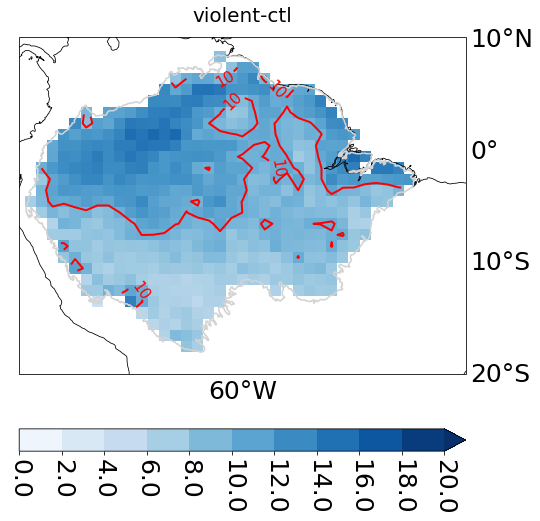

In [89]:
contourf(frequency_percent.calibrated_precipitation, 0, 20, 11, 'Blues', 'max','violent-ctl') # 23500-25500

In [127]:
mask_icon = icon_aw.pr > 0.95  # True/False array

# Compute frequency along the time dimension
# Since True=1 and False=0, taking the mean gives fraction of time
frequency_icon = mask_icon.mean(dim="time")
frequency_icon = frequency_icon.where(frequency_icon != 0, np.nan)

# frequency is now (lat, lon) with values between 0 and 1
# Multiply by 100 if you want percentage
frequency_percent_icon = frequency_icon * 100

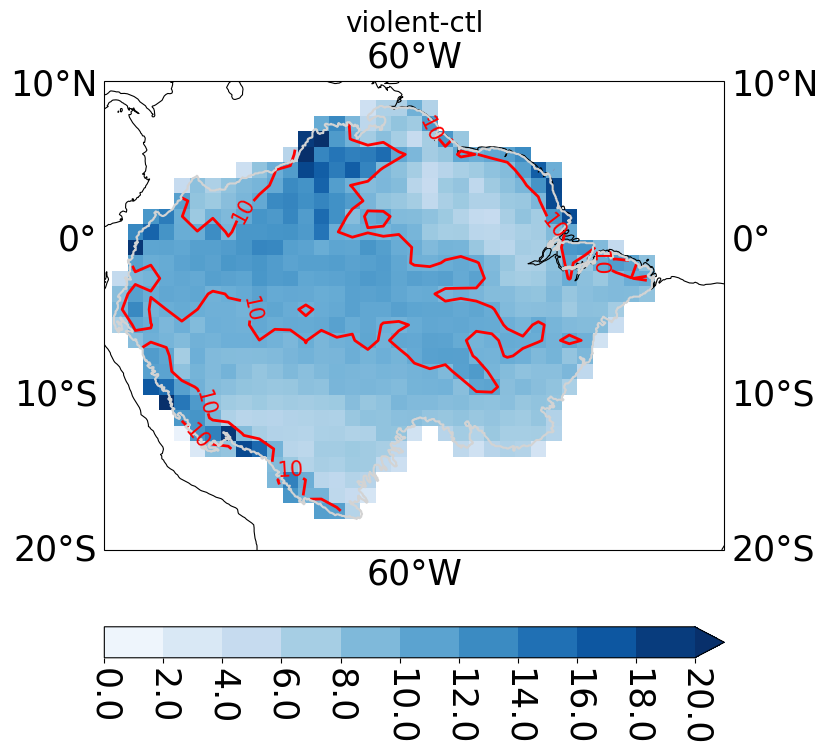

In [134]:
contourf(frequency_percent_icon, 0, 20, 11, 'Blues', 'max','violent-ctl') # 23500-25500

## Spatial correlation

In [94]:
# 1) Compute q90 per grid cell (reference threshold)
q = 0.90
imerg_q90 = imerg_mult_amz.quantile(q, dim="time", skipna=True)
icon_q90 = icon_aw.pr.quantile(q, dim="time", skipna=True)

In [149]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def plot_map(da, title, vmin=0, vmax=0.5, space=11, cmap="YlGnBu"):
    projection = ccrs.PlateCarree(central_longitude=180)
    fig = plt.figure(figsize=(8, 10), facecolor="w")
    ax = plt.axes(projection=projection)

    # Set your region as needed
    ax.set_extent([-80,-40,-19,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    m = ax.pcolormesh(da.lon, da.lat, da, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())

    
    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, space)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend='max',ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    
    plt.title(title)
    plt.show()


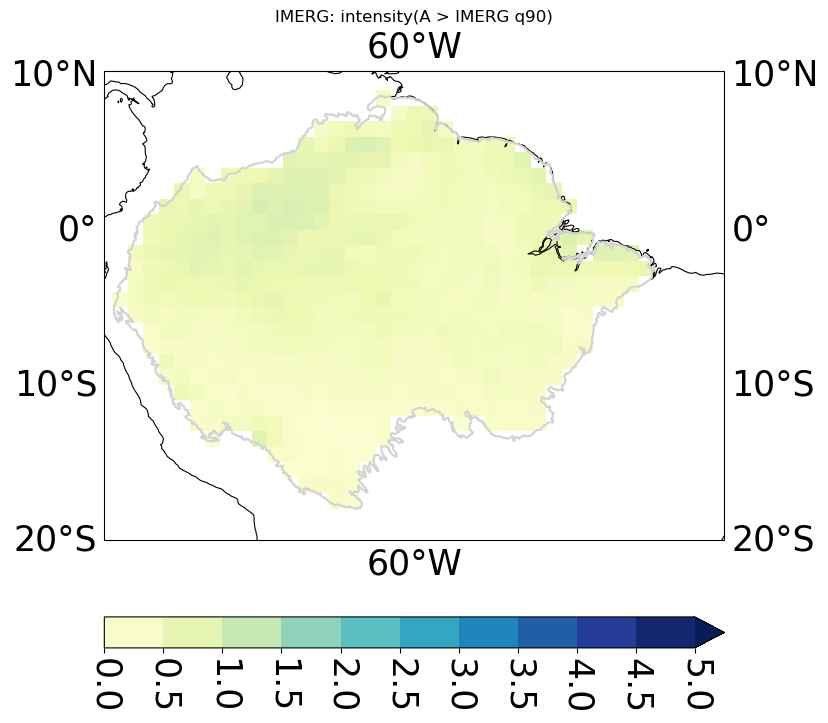

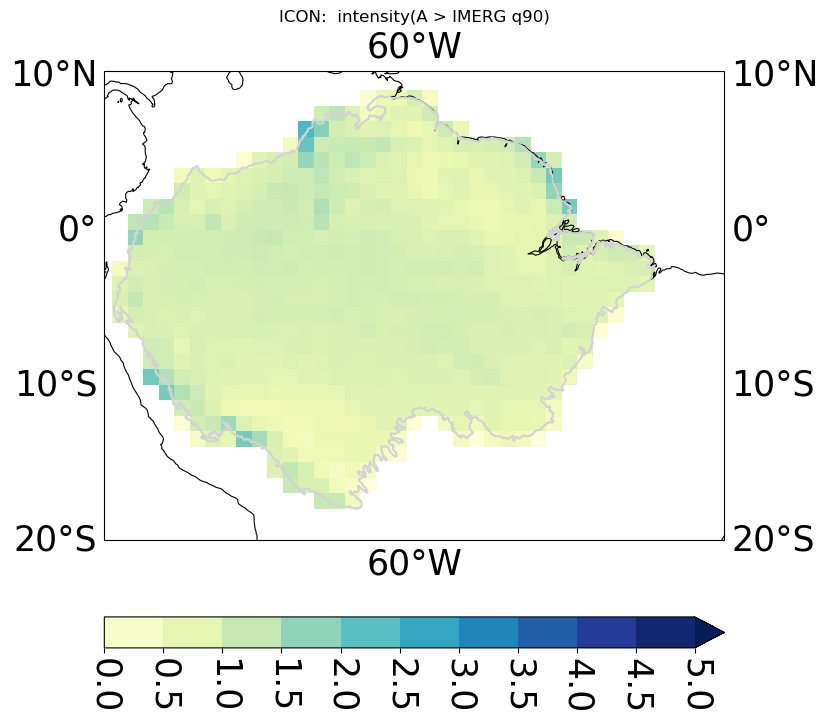

In [150]:
plot_map(imerg_q90, "IMERG: intensity(A > IMERG q90)", vmin=0, vmax=5, space=11, cmap="YlGnBu")
plot_map(icon_q90,  "ICON:  intensity(A > IMERG q90)", vmin=0, vmax=5, space=11, cmap="YlGnBu")